#### Dependencies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import statsmodels.api as sm

from lifelines import KaplanMeierFitter, CoxPHFitter, NelsonAalenFitter
from sklearn.model_selection import KFold
from scipy.stats import gaussian_kde, norm
from sklearn.model_selection import train_test_split
from matplotlib.ticker import FuncFormatter
from lifelines.plotting import add_at_risk_counts
from lifelines.utils import concordance_index

from __future__ import annotations
from collections import Counter
from dataclasses import dataclass
import hashlib
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from typing import Optional, List, Dict, Tuple

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from lifelines.statistics import logrank_test
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy.optimize import linear_sum_assignment


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None) 

#### Datasets

In [4]:
lical0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/lical0_processed_data_for_fp_model_21-01-2026.csv')
miro0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/miro0_processed_data_for_fp_model_21-01-2026.csv')
# ril_3010 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/ril_3010_processed_data_for_fp_model_21-01-2026.csv')

proact0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/proact0_processed_data_for_fp_model_21-01-2026.csv')

MND_lica = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/Sarah_MNDRegisterDataset_licals_02_amara.csv')
MND_miro = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/All_MNDRegisterDataset_mirocals_random_index_date.csv')
# MND_rilu = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/MNDRegisterDataset_riluzole.csv')

In [3]:
MND_miro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1838 entries, 0 to 1837
Data columns (total 65 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient_ID                       1838 non-null   float64
 1   Site_code                        1838 non-null   object 
 2   AgeOfOnset                       1838 non-null   float64
 3   SiteofOnset                      1798 non-null   object 
 4   Gender                           1820 non-null   object 
 5   AgeDeath                         1208 non-null   float64
 6   DiagnosticDelay_days             1434 non-null   float64
 7   YearFollowUp                     689 non-null    object 
 8   FVCLitres                        793 non-null    float64
 9   FVCPercentofPredicted            842 non-null    float64
 10  Diagnosis                        1838 non-null   object 
 11  Site_code_mndx                   1838 non-null   object 
 12  ConsentRegister     

In [5]:
miro0.head(3)

,subject_id,Event,Vital_capacity,El_Escorial,Onset_to_Rand,Age_Onset,Diagnostic_Delay,Study_Duration,Age_Diag,Enrollment_Delay,ALSFRS_RT,ALSFRS_Rasch,slope,Disease_DurationD,Onset_site_Limb,Sex_Male,Study_Arm_Placebo
0,1-62478,1,99.0,0,18.432,69.391,15.108,11.742444,70.650,3.324,39.0,28.4,-0.766450,15.066444,1,0,1
1,1-62479,1,81.0,1,19.644,63.754,15.600,5.500657,65.054,4.044,25.0,20.1,-4.181319,9.544657,0,0,0
2,1-62480,0,96.0,0,10.284,56.167,8.904,22.024967,56.909,1.380,42.0,31.1,-0.272418,23.404967,1,1,0


In [5]:
# miro0['Enrollment_Delay'] = miro0['Enrollment_Delay'] + 3

In [6]:
# miro0.head(3)

In [7]:
lical0.head(2)

,subject_id,Event,Vital_capacity,El_Escorial,Onset_to_Rand,Age_Onset,Diagnostic_Delay,Study_Duration,Age_Diag,Enrollment_Delay,ALSFRS_RT,ALSFRS_Rasch,slope,Disease_DurationD,Onset_site_Limb,Sex_Male,Study_Arm_Placebo
0,P01001,0,107.0,0,33.544148,51.967146,5.880420,19.000000,52.457221,27.660972,35.0,25.7,-0.684211,30.958607,1,1,1
1,P01002,1,99.0,0,18.562628,59.613963,9.526938,19.528252,60.407940,9.034166,43.0,32.2,-0.256039,27.562418,1,0,1


In [9]:
proact0.head(2)

,subject_id,Event,Vital_capacity,Age_Onset,Age_Diag,Diagnostic_Delay,Study_Duration_months,slope,ALSFRS_Rasch,ALSFRS_RT,Enrollment_Delay,Disease_DurationD,el_es,Onset_to_Rand,Onset_site_Limb,Sex_Male,Study_Arm_Placebo
0,121,1,63.037137,50.997947,51.584887,7.042707,17.557162,-1.196093,21.1,27.0,4.980946,22.538108,0,12.023653,1,0,0
1,226,1,56.228941,70.743326,71.594689,10.215506,13.910644,-1.581523,20.6,26.0,4.863338,18.773982,0,15.078844,0,1,0


In [9]:
# MND_miro.columns

In [10]:
MND_lica = MND_lica[['Patient_ID', 'New_event', 'FVCPercentofPredicted','AgeOfOnset', 'DiagnosticDelay_months',
                     'disease_duration_months', 'slope', 'ALSFRS_R', 'ElEscorial_Definite', 'Onset_Limb','Sex_Male']].copy()

MND_miro = MND_miro[['Patient_ID', 'Event', 'FVC_imputed','AgeOfOnset','DiagnosticDelay_months_imputed',
                     'disease_duration_months_imputed', 'Study_Duration_months', 'slope', 'ALSFRS_imputed', 'ElEscorial_Definite', 'Onset_Limb','Sex_Male']].copy()

In [11]:
# proact0 = proact0[proact0['Disease_Duration'] < 120]
lical0 = lical0.rename(columns={'Onset_site_Limb': 'Onset_Limb'})
miro0 = miro0.rename(columns={'Onset_site_Limb': 'Onset_Limb'})
proact0 = proact0.rename(columns={'Onset_site_Limb': 'Onset_Limb', 'el_es': 'El_Escorial', 'Study_Duration_months': 'Study_Duration'})

MND_lica = MND_lica.rename(columns={'Patient_ID': 'subject_id', 'New_event': 'Event', 'ElEscorial_Definite': 'El_Escorial', 'FVCPercentofPredicted': 'Vital_capacity',
                                    'AgeOfOnset': 'Age_Onset', 'ALSFRS_R': 'ALSFRS_RT', 'DiagnosticDelay_months': 'Diagnostic_Delay', 'disease_duration_months': 'Disease_DurationD'})

MND_miro = MND_miro.rename(columns={'Patient_ID': 'subject_id', 'ElEscorial_Definite': 'El_Escorial', 'FVC_imputed': 'Vital_capacity', 'Study_Duration_months': 'Study_Duration',
                                    'AgeOfOnset': 'Age_Onset', 'ALSFRS_imputed': 'ALSFRS_RT', 'DiagnosticDelay_months_imputed': 'Diagnostic_Delay', 'disease_duration_months_imputed': 'Disease_DurationD'})

In [12]:
lical0 = lical0.drop(['Age_Diag', 'Enrollment_Delay', 'ALSFRS_Rasch', 'Study_Duration'], axis=1)
lical0.head(2)

,subject_id,Event,Vital_capacity,El_Escorial,Onset_to_Rand,Age_Onset,Diagnostic_Delay,ALSFRS_RT,slope,Disease_DurationD,Onset_Limb,Sex_Male,Study_Arm_Placebo
0,P01001,0,107.0,0,33.544148,51.967146,5.880420,35.0,-0.684211,30.958607,1,1,1
1,P01002,1,99.0,0,18.562628,59.613963,9.526938,43.0,-0.256039,27.562418,1,0,1


In [13]:
miro0 = miro0.drop(['Age_Diag', 'Enrollment_Delay', 'ALSFRS_Rasch', 'Onset_to_Rand'], axis=1)
miro0.head(2)

,subject_id,Event,Vital_capacity,El_Escorial,Age_Onset,Diagnostic_Delay,Study_Duration,ALSFRS_RT,slope,Disease_DurationD,Onset_Limb,Sex_Male,Study_Arm_Placebo
0,1-62478,1,99.0,0,69.391,15.108,11.742444,39.0,-0.766450,15.066444,1,0,1
1,1-62479,1,81.0,1,63.754,15.600,5.500657,25.0,-4.181319,9.544657,0,0,0


In [14]:
proact0 = proact0.drop(['Age_Diag', 'Enrollment_Delay', 'ALSFRS_Rasch', 'Study_Duration'], axis=1)
proact0.head(2)

,subject_id,Event,Vital_capacity,Age_Onset,Diagnostic_Delay,slope,ALSFRS_RT,Disease_DurationD,El_Escorial,Onset_to_Rand,Onset_Limb,Sex_Male,Study_Arm_Placebo
0,121,1,63.037137,50.997947,7.042707,-1.196093,27.0,22.538108,0,12.023653,1,0,0
1,226,1,56.228941,70.743326,10.215506,-1.581523,26.0,18.773982,0,15.078844,0,1,0


In [15]:
MND_miro.head(2)

,subject_id,Event,Vital_capacity,Age_Onset,Diagnostic_Delay,Disease_DurationD,Study_Duration,slope,ALSFRS_RT,El_Escorial,Onset_Limb,Sex_Male
0,2.0,0,79.0,63.869999,3.613666,25.840042,21.0,-1.586685,7.0,0,1,1
1,3.0,0,127.0,69.480003,24.244415,289.000000,21.0,-0.114187,15.0,0,0,0


In [16]:
# MND_miro

In [17]:
MND_miro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1838 entries, 0 to 1837
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         1838 non-null   float64
 1   Event              1838 non-null   int64  
 2   Vital_capacity     1838 non-null   float64
 3   Age_Onset          1838 non-null   float64
 4   Diagnostic_Delay   1838 non-null   float64
 5   Disease_DurationD  1838 non-null   float64
 6   Study_Duration     1838 non-null   float64
 7   slope              1838 non-null   float64
 8   ALSFRS_RT          1838 non-null   float64
 9   El_Escorial        1838 non-null   int64  
 10  Onset_Limb         1838 non-null   int64  
 11  Sex_Male           1838 non-null   int64  
dtypes: float64(8), int64(4)
memory usage: 172.4 KB


##### Proact with eligibility criteria

In [18]:
# proact_miro = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/proact_miro_full.csv')
# proact_lica = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/proact_lica_full.csv')

# proact_miro['slope'] = (48 - proact_miro['ALSFRS_RT']) / proact_miro['Disease_Duration']
# proact_lica['slope'] = (48 - proact_lica['ALSFRS_RT']) / proact_lica['Disease_Duration']

# binss = [-np.inf, 0.31, 1.17, np.inf]
# labelss = ["Slow", "Intermediate", "Fast"]

# proact_miro["Progression_group"] = pd.cut(proact_miro["slope"], bins=binss, labels=labelss)
# proact_lica["Progression_group"] = pd.cut(proact_lica["slope"], bins=binss, labels=labelss)

#### **Select only the treatment arm**

In [19]:
lical0_trt = lical0[lical0['Study_Arm_Placebo'] == 0].copy()
miro0_trt = miro0[miro0['Study_Arm_Placebo'] == 0].copy()
# miroli0_trt = miroli0[miroli0['Study_Arm_Placebo'] == 0].copy()
# ril_3010_trt = ril_3010[ril_3010['Study_Arm_Placebo'] == 0].copy()
proact0_trt = proact0[proact0['Study_Arm_Placebo'] == 0].copy() 

#### **Select only the placebo arm**

In [20]:
lical0_pla = lical0[lical0['Study_Arm_Placebo'] == 1].copy()
miro0_pla = miro0[miro0['Study_Arm_Placebo'] == 1].copy()
# miroli0_pla = miroli0[miroli0['Study_Arm_Placebo'] == 1].copy()
# ril_3010_pla = ril_3010[ril_3010['Study_Arm_Placebo'] == 1].copy()
proact0_pla = proact0[proact0['Study_Arm_Placebo'] == 1].copy() 

#### **Choosing cohorts**

In [21]:
# MND_lica.columns

In [22]:
miro0_trt.columns

Index(['subject_id', 'Event', 'Vital_capacity', 'El_Escorial', 'Age_Onset',
       'Diagnostic_Delay', 'Study_Duration', 'ALSFRS_RT', 'slope',
       'Disease_DurationD', 'Onset_Limb', 'Sex_Male', 'Study_Arm_Placebo'],
      dtype='object')

In [23]:
MND_miro['Study_Arm_Placebo'] = 1
MND_lica['Study_Arm_Placebo'] = 1

# MND_miro = MND_miro.rename(columns={'TRICALS_Risk_Score': 'TRICALS'})
# MND_lica = MND_lica.rename(columns={'TRICALS_Risk_Score': 'TRICALS'})
MND_miro.head(2)

,subject_id,Event,Vital_capacity,Age_Onset,Diagnostic_Delay,Disease_DurationD,Study_Duration,slope,ALSFRS_RT,El_Escorial,Onset_Limb,Sex_Male,Study_Arm_Placebo
0,2.0,0,79.0,63.869999,3.613666,25.840042,21.0,-1.586685,7.0,0,1,1,1
1,3.0,0,127.0,69.480003,24.244415,289.000000,21.0,-0.114187,15.0,0,0,0,1


In [24]:
miro0_trt.head(2)

,subject_id,Event,Vital_capacity,El_Escorial,Age_Onset,Diagnostic_Delay,Study_Duration,ALSFRS_RT,slope,Disease_DurationD,Onset_Limb,Sex_Male,Study_Arm_Placebo
1,1-62479,1,81.0,1,63.754,15.600,5.500657,25.0,-4.181319,9.544657,0,0,0
2,1-62480,0,96.0,0,56.167,8.904,22.024967,42.0,-0.272418,23.404967,1,1,0


In [25]:
miro0_trt_for_mnd_data = miro0_trt #[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag', 'Diagnostic_Delay', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay', 'slope']]
lica0_trt_for_mnd_data = lical0_trt #[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag', 'Diagnostic_Delay', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay', 'slope']]

miro0_pla_for_mnd_data = miro0_pla #[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag', 'Diagnostic_Delay', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay', 'slope']]
lica0_pla_for_mnd_data = lical0_pla #[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag', 'Diagnostic_Delay', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay', 'slope']]


In [26]:
MND_miro.head(2)

,subject_id,Event,Vital_capacity,Age_Onset,Diagnostic_Delay,Disease_DurationD,Study_Duration,slope,ALSFRS_RT,El_Escorial,Onset_Limb,Sex_Male,Study_Arm_Placebo
0,2.0,0,79.0,63.869999,3.613666,25.840042,21.0,-1.586685,7.0,0,1,1,1
1,3.0,0,127.0,69.480003,24.244415,289.000000,21.0,-0.114187,15.0,0,0,0,1


#### **Propensity score matching**

In [27]:
# ============================================================
# PROPENSITY SCORE + OVERLAP
# ============================================================
def fit_ps_trim_weight(
    df: pd.DataFrame,
    covariates: List[str],
    penalty: str = "l2",
    C: float = 1.0,
    trim: bool = True,
    weight_method: str = "overlap",
    ps_col: str = "ps",
    group_col: str = "Group",
    verbose: bool = True
) -> Tuple[pd.DataFrame, Pipeline]:
    """
    Fit a logistic-regression propensity score model, optionally trim to common
    support, and add balancing weights.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing covariates and treatment/group indicator.
    covariates : List[str]
        Covariates used in the propensity score model.
    penalty : str, default="l2"
        LogisticRegression penalty.
    C : float, default=1.0
        Inverse regularization strength for LogisticRegression.
    trim : bool, default=True
        If True, trim observations outside the common support region.
    weight_method : str, default="overlap"
        Weighting scheme. Supported:
        - "overlap"
        - "iptw"
        - "unstabilized"
    ps_col : str, default="ps"
        Name of the propensity score column to create/use.
    group_col : str, default="Group"
        Name of binary treatment/group column (0 = control, 1 = treated).
    verbose : bool, default=True
        If True, print AUC and trimming summary.

    Returns
    -------
    Tuple[pd.DataFrame, Pipeline]
        Processed dataframe and fitted sklearn pipeline.
    """
    # -----------------------------
    # Validate inputs
    # -----------------------------
    required_cols = set(covariates + [group_col])
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    x = df[covariates].copy()
    y = df[group_col].astype(int).values

    if not set(np.unique(y)).issubset({0, 1}):
        raise ValueError(f"{group_col} must be binary with values 0/1.")

    # -----------------------------
    # Build and fit PS model
    # -----------------------------
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, covariates)
        ],
        remainder="drop"
    )

    model = LogisticRegression(
        penalty=penalty,
        C=C,
        solver="lbfgs",
        max_iter=5000
    )

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(x, y)
    ps = pipe.predict_proba(x)[:, 1]
    ps_clipped = np.clip(ps, 1e-6, 1 - 1e-6)

    out = df.copy()
    out[ps_col] = ps
    out["ps_logit"] = np.log(ps_clipped / (1 - ps_clipped))

    auc = roc_auc_score(y, ps)
    if verbose:
        print(f"Propensity model AUC: {auc:.3f}")

    # -----------------------------
    # Optional trimming
    # -----------------------------
    if trim:
        ps_t = out.loc[out[group_col] == 1, ps_col]
        ps_c = out.loc[out[group_col] == 0, ps_col]

        lower_common = max(ps_t.min(), ps_c.min())
        upper_common = min(ps_t.max(), ps_c.max())

        before_n = len(out)
        out = out[(out[ps_col] >= lower_common) & (out[ps_col] <= upper_common)].copy()
        out = out.reset_index(drop=True)

        if verbose:
            print(f"Before trimming: {before_n}")
            print(f"After trimming:  {len(out)}")
            print(f"Removed:         {before_n - len(out)}")

    # -----------------------------
    # Add weights
    # -----------------------------
    ps_final = np.clip(out[ps_col].values, 1e-6, 1 - 1e-6)
    g = out[group_col].astype(int).values

    if weight_method == "overlap":
        w = np.where(g == 1, 1 - ps_final, ps_final)
    elif weight_method in ("iptw", "unstabilized"):
        w = np.where(g == 1, 1 / ps_final, 1 / (1 - ps_final))
    else:
        raise ValueError("weight_method must be 'overlap' or 'iptw'")

    out["weight"] = w

    return out, pipe




# ============================================================
# BALANCE DIAGNOSTICS
# ============================================================
def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)


def weighted_var(x, w):
    mu = weighted_mean(x, w)
    return np.sum(w * (x - mu) ** 2) / np.sum(w)


def smd_continuous(x_t, x_c, w_t=None, w_c=None):
    x_t = np.asarray(x_t, dtype=float)
    x_c = np.asarray(x_c, dtype=float)

    if w_t is None:
        mt = np.nanmean(x_t)
        vt = np.nanvar(x_t, ddof=0)
    else:
        mt = weighted_mean(x_t, w_t)
        vt = weighted_var(x_t, w_t)

    if w_c is None:
        mc = np.nanmean(x_c)
        vc = np.nanvar(x_c, ddof=0)
    else:
        mc = weighted_mean(x_c, w_c)
        vc = weighted_var(x_c, w_c)

    pooled_sd = np.sqrt((vt + vc) / 2)
    if pooled_sd == 0 or np.isnan(pooled_sd):
        return np.nan
    return (mt - mc) / pooled_sd


def smd_binary(x_t, x_c, w_t=None, w_c=None):
    x_t = np.asarray(x_t, dtype=float)
    x_c = np.asarray(x_c, dtype=float)

    if w_t is None:
        pt = np.nanmean(x_t)
    else:
        pt = weighted_mean(x_t, w_t)

    if w_c is None:
        pc = np.nanmean(x_c)
    else:
        pc = weighted_mean(x_c, w_c)

    p = (pt + pc) / 2
    denom = np.sqrt(p * (1 - p))
    if denom == 0 or np.isnan(denom):
        return np.nan
    return (pt - pc) / denom


def balance_table(df: pd.DataFrame, covariates: List[str], weight_col: Optional[str] = None) -> pd.DataFrame:
    rows = []

    treated = df[df["Group"] == 1].copy()
    control = df[df["Group"] == 0].copy()

    for col in covariates:
        xt = treated[col].astype(float)
        xc = control[col].astype(float)

        mask_t = xt.notna()
        mask_c = xc.notna()
        xt = xt[mask_t]
        xc = xc[mask_c]

        wt = treated.loc[mask_t, weight_col].values if weight_col is not None else None
        wc = control.loc[mask_c, weight_col].values if weight_col is not None else None

        uniq = pd.concat([xt, xc]).dropna().unique()
        is_binary = set(np.unique(uniq)).issubset({0.0, 1.0})

        if is_binary:
            smd = smd_binary(xt, xc, wt, wc)
        else:
            smd = smd_continuous(xt, xc, wt, wc)

        if weight_col is None:
            mt = np.nanmean(xt)
            mc = np.nanmean(xc)
        else:
            mt = weighted_mean(xt.values, wt)
            mc = weighted_mean(xc.values, wc)

        rows.append({
            "Variable": col,
            "Treated_mean": mt,
            "Control_mean": mc,
            "SMD": smd,
            "Abs_SMD": np.abs(smd)
        })

    out = pd.DataFrame(rows).sort_values("Abs_SMD", ascending=False).reset_index(drop=True)
    return out


# ============================================================
# SURVIVAL ANALYSIS
# ============================================================
def weighted_km_plot(
    df: pd.DataFrame,
    time_col: str = "Time",
    event_col: str = "Event",
    weight_col: Optional[str] = "weight",
    title: str = "Weighted Kaplan-Meier",
    x_max: Optional[float] = None
):
    plt.figure(figsize=(5, 4))

    km_t = KaplanMeierFitter()
    km_c = KaplanMeierFitter()

    treated = df[df["Group"] == 1].copy()
    control = df[df["Group"] == 0].copy()

    km_t.fit(
        durations=treated[time_col],
        event_observed=treated[event_col],
        weights=treated[weight_col] if weight_col else None,
        label="Treated"
    )
    km_c.fit(
        durations=control[time_col],
        event_observed=control[event_col],
        weights=control[weight_col] if weight_col else None,
        label="External control"
    )

    ax = km_t.plot_survival_function(ci_show=True)
    km_c.plot_survival_function(ci_show=True, ax=ax)

    ax.set_xlabel("Disease Duration")
    ax.set_ylabel("Survival probability")
    ax.set_title(title)
    ax.set_ylim(0,1.02)
    ax.grid(True, alpha=0.3)
    if x_max is not None:
        ax.set_xlim(0, x_max)
    plt.tight_layout()
    plt.show()
    


#### **Prepare data**

In [28]:
# combine treated and  placebo patients
# lical and MND_lical
lica0_trt_for_mnd_data['data'] = "lical0_trt"
MND_lica['data'] = "MND_lica"
comb_mnd_lica_trt = pd.concat([lica0_trt_for_mnd_data, MND_lica], axis=0, ignore_index=True)
comb_mnd_lica_trt['Group'] = (comb_mnd_lica_trt['data'] == "lical0_trt").astype(int)

lica0_pla_for_mnd_data['data'] = "lical0_pla"
MND_lica['data'] = "MND_lica"
comb_mnd_lica_pla = pd.concat([lica0_pla_for_mnd_data, MND_lica], axis=0, ignore_index=True)
comb_mnd_lica_pla['Group'] = (comb_mnd_lica_pla['data'] == "lical0_pla").astype(int)

# mirocal and MND_mirocal
miro0_trt_for_mnd_data['data'] = "miro0_trt"
MND_miro['data'] = "MND_miro"
comb_mnd_miro_trt = pd.concat([miro0_trt_for_mnd_data, MND_miro], axis=0, ignore_index=True)
comb_mnd_miro_trt['Group'] = (comb_mnd_miro_trt['data'] == "miro0_trt").astype(int)

miro0_pla_for_mnd_data['data'] = "miro0_pla"
MND_miro['data'] = "MND_miro"
comb_mnd_miro_pla = pd.concat([miro0_pla_for_mnd_data, MND_miro], axis=0, ignore_index=True)
comb_mnd_miro_pla['Group'] = (comb_mnd_miro_pla['data'] == "miro0_pla").astype(int)


In [29]:
comb_mnd_miro_pla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1948 entries, 0 to 1947
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         1948 non-null   object 
 1   Event              1948 non-null   int64  
 2   Vital_capacity     1948 non-null   float64
 3   El_Escorial        1948 non-null   int64  
 4   Age_Onset          1948 non-null   float64
 5   Diagnostic_Delay   1948 non-null   float64
 6   Study_Duration     1948 non-null   float64
 7   ALSFRS_RT          1948 non-null   float64
 8   slope              1948 non-null   float64
 9   Disease_DurationD  1948 non-null   float64
 10  Onset_Limb         1948 non-null   int64  
 11  Sex_Male           1948 non-null   int64  
 12  Study_Arm_Placebo  1948 non-null   int64  
 13  data               1948 non-null   object 
 14  Group              1948 non-null   int64  
dtypes: float64(7), int64(6), object(2)
memory usage: 228.4+ KB


In [30]:
def log_transform_and_standardize_columns(df, cols):
    for col in cols:
        df[col + "_l"] = np.log1p(df[col])  # ln(1 + x)
    
    for col in df.select_dtypes(include=['float']).columns:
        df[col + '_std'] = (df[col] - df[col].mean()) / df[col].std()
    return df

cols_to_transform = ['Diagnostic_Delay']

comb_mnd_lica_trt = log_transform_and_standardize_columns(comb_mnd_lica_trt, cols_to_transform)
comb_mnd_miro_trt = log_transform_and_standardize_columns(comb_mnd_miro_trt, cols_to_transform)
comb_mnd_lica_pla = log_transform_and_standardize_columns(comb_mnd_lica_pla, cols_to_transform)
comb_mnd_miro_pla = log_transform_and_standardize_columns(comb_mnd_miro_pla, cols_to_transform)

comb_mnd_miro_trt.head(2)

,subject_id,Event,Vital_capacity,El_Escorial,Age_Onset,Diagnostic_Delay,Study_Duration,ALSFRS_RT,slope,Disease_DurationD,Onset_Limb,Sex_Male,Study_Arm_Placebo,data,Group,Diagnostic_Delay_l,Vital_capacity_std,Age_Onset_std,Diagnostic_Delay_std,Study_Duration_std,ALSFRS_RT_std,slope_std,Disease_DurationD_std,Diagnostic_Delay_l_std
0,1-62479,1,81.0,1,63.754,15.600,5.500657,25.0,-4.181319,9.544657,0,0,0,miro0_trt,1,2.809403,-1.261706,0.568878,-0.106247,-2.546482,-1.125445,-1.800390,-0.807437,0.241402
1,1-62480,0,96.0,0,56.167,8.904,22.024967,42.0,-0.272418,23.404967,1,1,0,miro0_trt,1,2.292939,-0.127689,-0.093332,-0.421298,0.684641,0.951908,0.233411,-0.531908,-0.476898


In [31]:
# comb_mnd_miro_trt.describe()

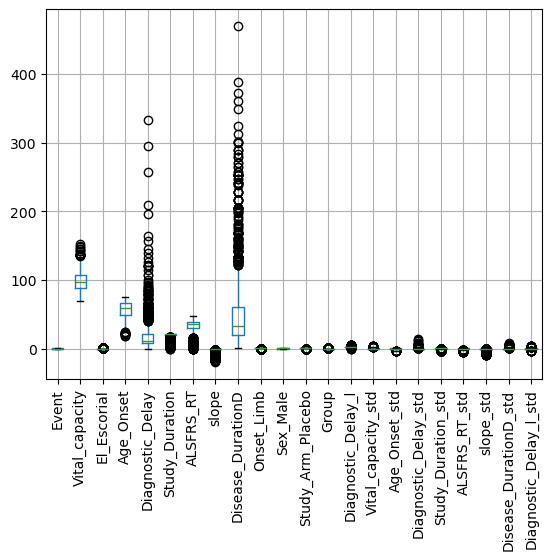

In [32]:
comb_mnd_miro_trt.boxplot(rot=90)
plt.show()

In [33]:
# comb_mnd_lica_trt["ALSFRS_RT_std"].hist()

In [34]:
comb_mnd_miro_trt.columns

Index(['subject_id', 'Event', 'Vital_capacity', 'El_Escorial', 'Age_Onset',
       'Diagnostic_Delay', 'Study_Duration', 'ALSFRS_RT', 'slope',
       'Disease_DurationD', 'Onset_Limb', 'Sex_Male', 'Study_Arm_Placebo',
       'data', 'Group', 'Diagnostic_Delay_l', 'Vital_capacity_std',
       'Age_Onset_std', 'Diagnostic_Delay_std', 'Study_Duration_std',
       'ALSFRS_RT_std', 'slope_std', 'Disease_DurationD_std',
       'Diagnostic_Delay_l_std'],
      dtype='object')

In [35]:
comb_mnd_lica_trt = comb_mnd_lica_trt[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Onset_std', 'Diagnostic_Delay_l_std','El_Escorial', 'Sex_Male', 'Onset_Limb', 'ALSFRS_RT_std', 'Vital_capacity_std','data', 'Group', 'slope_std']]
comb_mnd_miro_trt = comb_mnd_miro_trt[['subject_id', 'Event', 'Study_Duration','Study_Arm_Placebo', 'Age_Onset_std', 'Diagnostic_Delay_l_std','El_Escorial', 'Sex_Male', 'Onset_Limb', 'ALSFRS_RT_std', 'Vital_capacity_std','data', 'Group', 'slope_std']]
comb_mnd_lica_pla = comb_mnd_lica_pla[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Onset_std', 'Diagnostic_Delay_l_std','El_Escorial', 'Sex_Male', 'Onset_Limb', 'ALSFRS_RT_std', 'Vital_capacity_std','data', 'Group', 'slope_std']]
comb_mnd_miro_pla = comb_mnd_miro_pla[['subject_id', 'Event', 'Study_Duration','Study_Arm_Placebo', 'Age_Onset_std', 'Diagnostic_Delay_l_std', 'El_Escorial','Sex_Male', 'Onset_Limb', 'ALSFRS_RT_std', 'Vital_capacity_std','data', 'Group', 'slope_std']]

comb_mnd_lica_trt = comb_mnd_lica_trt.rename(columns={'Disease_DurationD': 'Disease_Duration', 'Diagnostic_Delay_l_std': 'Diagnostic_Delay', 'ALSFRS_RT_std':'ALSFRS', 'Age_Onset_std': 'Age', 'slope_std': 'slope', 'Vital_capacity_std': 'Vital_capacity'})
comb_mnd_miro_trt = comb_mnd_miro_trt.rename(columns={'Study_Duration': 'Disease_Duration', 'Diagnostic_Delay_l_std': 'Diagnostic_Delay', 'ALSFRS_RT_std':'ALSFRS', 'Age_Onset_std': 'Age', 'slope_std': 'slope', 'Vital_capacity_std': 'Vital_capacity'})
comb_mnd_lica_pla = comb_mnd_lica_pla.rename(columns={'Disease_DurationD': 'Disease_Duration', 'Diagnostic_Delay_l_std': 'Diagnostic_Delay', 'ALSFRS_RT_std':'ALSFRS', 'Age_Onset_std': 'Age', 'slope_std': 'slope', 'Vital_capacity_std': 'Vital_capacity'})
comb_mnd_miro_pla = comb_mnd_miro_pla.rename(columns={'Study_Duration': 'Disease_Duration', 'Diagnostic_Delay_l_std': 'Diagnostic_Delay', 'ALSFRS_RT_std':'ALSFRS', 'Age_Onset_std': 'Age', 'slope_std': 'slope', 'Vital_capacity_std': 'Vital_capacity'})

comb_mnd_lica_trt.head(2)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,El_Escorial,Sex_Male,Onset_Limb,ALSFRS,Vital_capacity,data,Group,slope
0,P01003,0,27.949409,0,-1.162149,-1.215391,0,1,1,1.013816,0.694002,lical0_trt,1,0.358018
1,P01004,0,26.402431,0,-1.063887,-1.965942,0,1,1,1.152002,0.502150,lical0_trt,1,0.378553


In [36]:
comb_mnd_miro_trt.head(3)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,El_Escorial,Sex_Male,Onset_Limb,ALSFRS,Vital_capacity,data,Group,slope
0,1-62479,1,5.500657,0,0.568878,0.241402,1,0,0,-1.125445,-1.261706,miro0_trt,1,-1.800390
1,1-62480,0,22.024967,0,-0.093332,-0.476898,0,1,1,0.951908,-0.127689,miro0_trt,1,0.233411
2,1-62482,1,9.541393,0,1.020738,-0.404661,1,0,0,0.707514,1.006328,miro0_trt,1,-0.061097


In [37]:
comb_mnd_miro_trt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1948 entries, 0 to 1947
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         1948 non-null   object 
 1   Event              1948 non-null   int64  
 2   Disease_Duration   1948 non-null   float64
 3   Study_Arm_Placebo  1948 non-null   int64  
 4   Age                1948 non-null   float64
 5   Diagnostic_Delay   1948 non-null   float64
 6   El_Escorial        1948 non-null   int64  
 7   Sex_Male           1948 non-null   int64  
 8   Onset_Limb         1948 non-null   int64  
 9   ALSFRS             1948 non-null   float64
 10  Vital_capacity     1948 non-null   float64
 11  data               1948 non-null   object 
 12  Group              1948 non-null   int64  
 13  slope              1948 non-null   float64
dtypes: float64(6), int64(6), object(2)
memory usage: 213.2+ KB


In [38]:
# comb_mnd_lica_trt['Diagnostic_Delay'].corr(comb_mnd_lica_trt['Disease_Duration'])

#### **Implement propensity score**

 **comb_mnd_lica_trt, comb_mnd_lica_pla, comb_mnd_miro_trt, comb_mnd_miro_pla**

 **comb_proact_lica_trt,  comb_proact_lica_pla, comb_proact_miro_trt, comb_proact_miro_pla**
 
 **comb_mnd_proact_miro_trt, comb_mnd_proact_miro_pla,  comb_mnd_proact_lica_trt, comb_mnd_proact_lica_pla**

In [39]:
comb_mnd_miro_trt.head(2)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,El_Escorial,Sex_Male,Onset_Limb,ALSFRS,Vital_capacity,data,Group,slope
0,1-62479,1,5.500657,0,0.568878,0.241402,1,0,0,-1.125445,-1.261706,miro0_trt,1,-1.800390
1,1-62480,0,22.024967,0,-0.093332,-0.476898,0,1,1,0.951908,-0.127689,miro0_trt,1,0.233411


In [40]:
comb_mnd_miro_trt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1948 entries, 0 to 1947
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         1948 non-null   object 
 1   Event              1948 non-null   int64  
 2   Disease_Duration   1948 non-null   float64
 3   Study_Arm_Placebo  1948 non-null   int64  
 4   Age                1948 non-null   float64
 5   Diagnostic_Delay   1948 non-null   float64
 6   El_Escorial        1948 non-null   int64  
 7   Sex_Male           1948 non-null   int64  
 8   Onset_Limb         1948 non-null   int64  
 9   ALSFRS             1948 non-null   float64
 10  Vital_capacity     1948 non-null   float64
 11  data               1948 non-null   object 
 12  Group              1948 non-null   int64  
 13  slope              1948 non-null   float64
dtypes: float64(6), int64(6), object(2)
memory usage: 213.2+ KB


In [41]:
covariates = ['Age', 'Disease_Duration', 'Onset_Limb', 'Sex_Male', 'El_Escorial', 'Vital_capacity', 'Diagnostic_Delay', 'ALSFRS'] #, 'Enrollment_Delay'

df_mnd_lica_trt, ps_mnd_lica_trt = fit_ps_trim_weight(df=comb_mnd_lica_trt, covariates=covariates, trim=False, weight_method="iptw") # iptw overlap
df_mnd_lica_pla, ps_mnd_lica_pla = fit_ps_trim_weight(df=comb_mnd_lica_pla, covariates=covariates, trim=False, weight_method="iptw")
df_mnd_miro_trt, ps_mnd_miro_trt = fit_ps_trim_weight(df=comb_mnd_miro_trt, covariates=covariates, trim=False, weight_method="iptw")
df_mnd_miro_pla, ps_mnd_miro_pla = fit_ps_trim_weight(df=comb_mnd_miro_pla, covariates=covariates, trim=False, weight_method="iptw")

Propensity model AUC: 0.874
Propensity model AUC: 0.885
Propensity model AUC: 0.839
Propensity model AUC: 0.820


In [42]:
comb_mnd_miro_trt.shape, df_mnd_miro_trt.shape

((1948, 14), (1948, 17))

In [43]:
df_mnd_miro_pla.head(3)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,El_Escorial,Sex_Male,Onset_Limb,ALSFRS,Vital_capacity,data,Group,slope,ps,ps_logit,weight
0,1-62478,1,11.742444,1,1.055609,0.194992,0,0,1,0.589500,0.100475,miro0_pla,1,-0.022171,0.028464,-3.530244,35.132294
1,1-62481,0,22.024967,1,1.151950,-0.791189,0,1,0,0.589500,-0.573955,miro0_pla,1,0.163602,0.034901,-3.319704,28.652152
2,1-62485,0,22.024967,1,-0.136804,-1.146821,0,1,1,1.442041,-0.648892,miro0_pla,1,0.328607,0.137246,-1.838359,7.286213


#### **Perform trial and register matching**

In [44]:
# df_mnd_lica_trt, df_mnd_lica_pla, df_mnd_miro_trt, df_mnd_miro_pla,

def trail_register_matched_with_replacement(df):
    # Split trial and register patients
    trial = df[df['Group'] == 1].copy()
    register = df[df['Group'] == 0].copy()

    trial = trial.reset_index(drop=True)
    register = register.reset_index(drop=True)

    # Nearest-neighbour matching
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(register[['ps']])
    distances, indices = nn.kneighbors(trial[['ps']])

    # Extract matched register controls
    matched_register = register.iloc[indices.flatten()].copy()
    matched_register['matched_trial_id'] = trial.index.values
    matched_register['ps_distance'] = distances.flatten()

    # combine matched trial and matched controls
    matched_trial = trial.copy()
    matched_trial['matched_trial_id'] = trial.index.values
    matched_trial['ps_distance'] = 0

    matched_data = pd.concat([matched_trial, matched_register], axis=0)
    return matched_data
# matched_data.shape


def trail_register_matched_without_replacement(df, caliper=0.05):
    trial = df[df["Group"] == 1].copy().reset_index(drop=True)
    register = df[df["Group"] == 0].copy().reset_index(drop=True)

    cost_matrix = np.abs(
        trial["ps"].values[:, None] - register["ps"].values[None, :]
    )

    penalty = 1e6
    cost_matrix_penalised = cost_matrix.copy()
    cost_matrix_penalised[cost_matrix_penalised > caliper] = penalty

    trial_indices, register_indices = linear_sum_assignment(cost_matrix_penalised)

    valid = cost_matrix_penalised[trial_indices, register_indices] < penalty

    trial_indices = trial_indices[valid]
    register_indices = register_indices[valid]

    matched_trial = trial.iloc[trial_indices].copy()
    matched_register = register.iloc[register_indices].copy()

    matched_trial["matched_trial_id"] = trial_indices
    matched_trial["ps_distance"] = 0

    matched_register["matched_trial_id"] = trial_indices
    matched_register["ps_distance"] = cost_matrix[trial_indices, register_indices]

    matched_data = pd.concat([matched_trial, matched_register], axis=0)

    return matched_data.reset_index(drop=True)


def trail_register_matched_without_replacement_keep_all_trial(df, caliper=0.05):
    trial = df[df["Group"] == 1].copy().reset_index(drop=True)
    register = df[df["Group"] == 0].copy().reset_index(drop=True)

    cost_matrix = np.abs(
        trial["ps"].values[:, None] - register["ps"].values[None, :]
    )

    penalty = 1e6
    cost_matrix_penalised = cost_matrix.copy()
    cost_matrix_penalised[cost_matrix_penalised > caliper] = penalty

    trial_indices, register_indices = linear_sum_assignment(cost_matrix_penalised)

    valid = cost_matrix_penalised[trial_indices, register_indices] < penalty

    valid_trial_indices = trial_indices[valid]
    valid_register_indices = register_indices[valid]

    # Keep ALL trial patients
    matched_trial = trial.copy()
    matched_trial["matched_trial_id"] = matched_trial.index
    matched_trial["ps_distance"] = 0
    matched_trial["matched_status"] = "trial_retained"

    # Keep only successfully matched register controls
    matched_register = register.iloc[valid_register_indices].copy()
    matched_register["matched_trial_id"] = valid_trial_indices
    matched_register["ps_distance"] = cost_matrix[
        valid_trial_indices,
        valid_register_indices
    ]
    matched_register["matched_status"] = "register_matched"

    matched_data = pd.concat(
        [matched_trial, matched_register],
        axis=0
    )

    return matched_data.reset_index(drop=True)


def trial_register_matched_one_to_many_keep_all_trial(df, n_matches=3, caliper=0.05):
    trial = df[df["Group"] == 1].copy().reset_index(drop=True)
    register = df[df["Group"] == 0].copy().reset_index(drop=True)

    used_register = set()
    matched_register_list = []

    # keep all trial patients
    matched_trial = trial.copy()
    matched_trial["matched_trial_id"] = matched_trial.index
    matched_trial["ps_distance"] = 0
    matched_trial["matched_status"] = "trial_retained"

    for i, trial_row in trial.iterrows():

        # available register patients only
        available_register = register.loc[
            ~register.index.isin(used_register)
        ].copy()

        if available_register.empty:
            continue

        # calculate distance in propensity score
        available_register["ps_distance"] = abs(
            available_register["ps"] - trial_row["ps"]
        )

        # keep only within caliper
        available_register = available_register[
            available_register["ps_distance"] <= caliper
        ]

        if available_register.empty:
            continue

        # choose nearest n_matches register patients
        selected = available_register.sort_values("ps_distance").head(n_matches).copy()

        selected["matched_trial_id"] = i
        selected["matched_status"] = "register_matched"

        matched_register_list.append(selected)

        # mark these register patients as already used
        used_register.update(selected.index.tolist())

    if matched_register_list:
        matched_register = pd.concat(matched_register_list, axis=0)
        matched_data = pd.concat([matched_trial, matched_register], axis=0)
    else:
        matched_data = matched_trial.copy()

    return matched_data.reset_index(drop=True)



In [45]:
# df_mnd_lica_trt, df_mnd_lica_pla, df_mnd_miro_trt, df_mnd_miro_pla,
# matched_data_wr = trail_register_matched_with_replacement(df_mnd_lica_trt)
matched_data_wor_mnd_lica_trt = trail_register_matched_without_replacement_keep_all_trial(df_mnd_lica_trt, caliper=0.05)
matched_data_wor_mnd_lica_pla = trail_register_matched_without_replacement_keep_all_trial(df_mnd_lica_pla, caliper=0.05)
matched_data_wor_mnd_miro_trt = trail_register_matched_without_replacement_keep_all_trial(df_mnd_miro_trt, caliper=0.05)
matched_data_wor_mnd_miro_pla = trail_register_matched_without_replacement_keep_all_trial(df_mnd_miro_pla, caliper=0.05)

# matched_data_wor_mnd_lica_trt_many = trial_register_matched_one_to_many_keep_all_trial(df_mnd_lica_trt, n_matches=3, caliper=0.1)
# matched_data_wor_mnd_lica_pla_many = trial_register_matched_one_to_many_keep_all_trial(df_mnd_lica_pla, n_matches=3, caliper=0.1)
matched_data_wor_mnd_miro_trt_many = trial_register_matched_one_to_many_keep_all_trial(df_mnd_miro_trt, n_matches=5, caliper=0.05)
matched_data_wor_mnd_miro_pla_many = trial_register_matched_one_to_many_keep_all_trial(df_mnd_miro_pla, n_matches=5, caliper=0.05)

# matched_data.groupby('Group')['ps'].describe()
# matched_data.groupby('Group')[covariates + ['ps']].mean()
matched_data_wor_mnd_miro_trt_many.shape# , matched_data_wr.shape

(574, 20)

In [46]:
print(matched_data_wor_mnd_miro_trt_many["Group"].value_counts())
matched_data_wor_mnd_miro_trt_many["matched_status"].value_counts()
# matched_data_wor_mnd_lica_trt_many.groupby(["matched_trial_id", "Group"]).size()

Group
0    464
1    110
Name: count, dtype: int64


matched_status
register_matched    464
trial_retained      110
Name: count, dtype: int64

#### **Implementation**

In [47]:
print(matched_data_wor_mnd_miro_trt_many.data.value_counts())
print()
print(matched_data_wor_mnd_miro_pla_many.data.value_counts())

data
MND_miro     464
miro0_trt    110
Name: count, dtype: int64

data
MND_miro     465
miro0_pla    110
Name: count, dtype: int64


In [48]:
mnd_pla_for_trial_trt = matched_data_wor_mnd_miro_trt_many[matched_data_wor_mnd_miro_trt_many['data'] == 'MND_miro'].copy()
mnd_pla_for_trial_pla = matched_data_wor_mnd_miro_pla_many[matched_data_wor_mnd_miro_pla_many['data'] == 'MND_miro'].copy()

# mnd_pla_for_trial_pla['weight'] = 1
mnd_pla_for_trial_trt.head(3)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,El_Escorial,Sex_Male,Onset_Limb,ALSFRS,Vital_capacity,data,Group,slope,ps,ps_logit,weight,matched_trial_id,ps_distance,matched_status
110,1760.0,1,11.124000,1,1.483246,-0.024269,0,1,0,0.526662,-0.052088,MND_miro,0,0.177852,0.013310,-4.305874,1.013489,0,0.000006,register_matched
111,299.0,1,13.932013,1,0.345960,-0.768586,0,0,0,0.303041,1.611137,MND_miro,0,0.153591,0.013307,-4.306096,1.013486,0,0.000008,register_matched
112,732.0,1,12.791989,1,-1.292326,-0.976886,0,0,1,-1.083898,-1.110503,MND_miro,0,-0.261460,0.013350,-4.302763,1.013531,0,0.000035,register_matched


In [49]:
trial_trt = matched_data_wor_mnd_miro_trt_many[matched_data_wor_mnd_miro_trt_many["data"] == 'miro0_trt'].copy()
trial_pla = matched_data_wor_mnd_miro_pla_many[matched_data_wor_mnd_miro_pla_many['data'] == "miro0_pla"].copy()

trial_trt['weight'] = 1
trial_pla['weight'] = 1

In [50]:
mnd_pla_for_trial_trt.head(2)
trial_trt.head(2)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,El_Escorial,Sex_Male,Onset_Limb,ALSFRS,Vital_capacity,data,Group,slope,ps,ps_logit,weight,matched_trial_id,ps_distance,matched_status
0,1-62479,1,5.500657,0,0.568878,0.241402,1,0,0,-1.125445,-1.261706,miro0_trt,1,-1.800390,0.013315,-4.305454,1,0,0.0,trial_retained
1,1-62480,0,22.024967,0,-0.093332,-0.476898,0,1,1,0.951908,-0.127689,miro0_trt,1,0.233411,0.079794,-2.445145,1,1,0.0,trial_retained


#### ***Implement Gaussian Copula***

In [51]:
trial = trial_trt.copy()
print(trial.shape)
trial.head(2)

(110, 20)


,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,El_Escorial,Sex_Male,Onset_Limb,ALSFRS,Vital_capacity,data,Group,slope,ps,ps_logit,weight,matched_trial_id,ps_distance,matched_status
0,1-62479,1,5.500657,0,0.568878,0.241402,1,0,0,-1.125445,-1.261706,miro0_trt,1,-1.800390,0.013315,-4.305454,1,0,0.0,trial_retained
1,1-62480,0,22.024967,0,-0.093332,-0.476898,0,1,1,0.951908,-0.127689,miro0_trt,1,0.233411,0.079794,-2.445145,1,1,0.0,trial_retained


In [52]:
virtual = mnd_pla_for_trial_trt.copy()
print(virtual.shape)
print(virtual.subject_id.nunique())
virtual.head(2)

(464, 20)
464


,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,El_Escorial,Sex_Male,Onset_Limb,ALSFRS,Vital_capacity,data,Group,slope,ps,ps_logit,weight,matched_trial_id,ps_distance,matched_status
110,1760.0,1,11.124000,1,1.483246,-0.024269,0,1,0,0.526662,-0.052088,MND_miro,0,0.177852,0.013310,-4.305874,1.013489,0,0.000006,register_matched
111,299.0,1,13.932013,1,0.345960,-0.768586,0,0,0,0.303041,1.611137,MND_miro,0,0.153591,0.013307,-4.306096,1.013486,0,0.000008,register_matched


In [53]:
MND_miro.head(2)

,subject_id,Event,Vital_capacity,Age_Onset,Diagnostic_Delay,Disease_DurationD,Study_Duration,slope,ALSFRS_RT,El_Escorial,Onset_Limb,Sex_Male,Study_Arm_Placebo,data
0,2.0,0,79.0,63.869999,3.613666,25.840042,21.0,-1.586685,7.0,0,1,1,1,MND_miro
1,3.0,0,127.0,69.480003,24.244415,289.000000,21.0,-0.114187,15.0,0,0,0,1,MND_miro


In [54]:
matched_mnd_miro = pd.merge(virtual, MND_miro, on = 'subject_id', how = 'left')
print(matched_mnd_miro.shape)
matched_mnd_miro.head(2)

(464, 33)


,subject_id,Event_x,Disease_Duration,Study_Arm_Placebo_x,Age,Diagnostic_Delay_x,El_Escorial_x,Sex_Male_x,Onset_Limb_x,ALSFRS,Vital_capacity_x,data_x,Group,slope_x,ps,ps_logit,weight,matched_trial_id,ps_distance,matched_status,Event_y,Vital_capacity_y,Age_Onset,Diagnostic_Delay_y,Disease_DurationD,Study_Duration,slope_y,ALSFRS_RT,El_Escorial_y,Onset_Limb_y,Sex_Male_y,Study_Arm_Placebo_y,data_y
0,1760.0,1,11.124000,1,1.483246,-0.024269,0,1,0,0.526662,-0.052088,MND_miro,0,0.177852,0.013310,-4.305874,1.013489,0,0.000006,register_matched,1,97.0,74.230003,12.713535,25.000000,11.124000,-0.379200,38.52,0,0,1,1,MND_miro
1,299.0,1,13.932013,1,0.345960,-0.768586,0,0,0,0.303041,1.611137,MND_miro,0,0.153591,0.013307,-4.306096,1.013486,0,0.000008,register_matched,1,119.0,61.200001,7.030223,26.560013,13.932013,-0.425828,36.69,0,0,0,1,MND_miro


In [55]:
matched_mnd_miro.columns

matched_mnd_miros = matched_mnd_miro[['subject_id', 'Disease_Duration', 'Event_y', 'Vital_capacity_y',
                 'Age_Onset', 'Diagnostic_Delay_y', 'slope_y', 'ALSFRS_RT',
                 'El_Escorial_y', 'Onset_Limb_y', 'Sex_Male_y', 'weight']].copy()

matched_mnd_miros = matched_mnd_miros.rename(columns={'Event_y': 'Event', 'Vital_capacity_y': 'Vital_capacity', 'Age_Onset': 'Age',
                 'Diagnostic_Delay_y': 'Diagnostic_Delay', 'slope_y': 'slope', 'ALSFRS_RT': 'ALSFRS', 'El_Escorial_y': 'El_Escorial',
                  'Onset_Limb_y': 'Onset_Limb', 'Sex_Male_y': 'Sex_Male'})
matched_mnd_miros.head(2)

,subject_id,Disease_Duration,Event,Vital_capacity,Age,Diagnostic_Delay,slope,ALSFRS,El_Escorial,Onset_Limb,Sex_Male,weight
0,1760.0,11.124000,1,97.0,74.230003,12.713535,-0.379200,38.52,0,0,1,1.013489
1,299.0,13.932013,1,119.0,61.200001,7.030223,-0.425828,36.69,0,0,0,1.013486


In [56]:
cph_synthetic = CoxPHFitter()

cph_synthetic.fit(matched_mnd_miros.drop(columns=['subject_id', 'slope']), duration_col = 'Disease_Duration', event_col = 'Event',
                    weights_col="weight")

cph_synthetic.print_summary()

<lifelines.CoxPHFitter: fitted with 539.354 total observations, 343.05 right-censored observations>
             duration col = 'Disease_Duration'
                event col = 'Event'
              weights col = 'weight'
      baseline estimation = breslow
   number of observations = 539.354
number of events observed = 196.304
   partial log-likelihood = -1153.18
         time fit was run = 2026-06-30 08:46:18 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
Vital_capacity   -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
Age               0.01      1.01      0.01            0.00            0.03                1.00                1.03
Diagnostic_Delay -0.07      0.93      0.02           -0.10           -0.04                0.90                0.96
ALSFRS           -0.02      0.98      0.02           -0.05            0.01                0.95                1.01
El_Escorial       0.72      2.06      0.18            0.37            1.07                1.45                2.92
Onset_Limb       -0.51      0.60      0.16           -0.83           -0.20                0.44                0.82
Sex_Male          0.10      1.11      0.15           -0.19            0.40                0.82                1.49

                  cmp to     z      p  -log2(p)
covariate                                      
Vital_capacity      0.00 -1.22   0.22      2.16
Age                 0.00  2.08   0.04      4.74
Diagnostic_Delay    0.00 -4.78 <0.005     19.11
ALSFRS              0.00 -1.49   0.14      2.88
El_Escorial         0.00  4.04 <0.005     14.22
Onset_Limb          0.00 -3.20 <0.005      9.50
Sex_Male            0.00  0.68   0.49      1.02
---
Concordance = 0.69
Partial AIC = 2320.37
log-likelihood ratio test = 81.67 on 7 df
-log2(p) of ll-ratio test = 47.18

In [57]:
from scipy.stats import norm, rankdata

class GaussianCopulaSynthesizer:
    def __init__(self, categorical_cols=None, random_state=42):
        self.categorical_cols = categorical_cols or []
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)

    def fit(self, df):
        self.columns = df.columns.tolist()
        self.continuous_cols = [col for col in self.columns if col not in self.categorical_cols]

        self.marginals = {}
        u_data = pd.DataFrame(index=df.index)

        for col in self.columns:
            x = df[col].dropna()

            if col in self.categorical_cols:
                probs = x.value_counts(normalize=True).sort_index()
                self.marginals[col] = {
                    "type": "categorical",
                    "categories": probs.index.tolist(),
                    "probs": probs.values
                }

                # Convert categories to empirical CDF ranks
                codes = pd.Categorical(df[col], categories=probs.index).codes
                codes = np.where(codes < 0, np.nan, codes)

                ranks = rankdata(codes[~np.isnan(codes)], method="average")
                u = np.full(len(df), np.nan)
                u[~np.isnan(codes)] = ranks / (len(ranks) + 1)

            else:
                sorted_x = np.sort(x.values)

                self.marginals[col] = {
                    "type": "continuous",
                    "values": sorted_x
                }

                ranks = rankdata(df[col], method="average", nan_policy="omit")
                u = ranks / (np.sum(~df[col].isna()) + 1)

            u_data[col] = u

        # Convert uniform variables to normal scores
        z_data = u_data.apply(lambda s: norm.ppf(np.clip(s, 1e-6, 1 - 1e-6)))

        # Replace missing with column mean
        z_data = z_data.fillna(z_data.mean())

        self.corr = np.corrcoef(z_data.T)

        # Stabilise correlation matrix
        self.corr = self._nearest_positive_definite(self.corr)

        return self

    def sample(self, n):
        z = self.rng.multivariate_normal(
            mean=np.zeros(len(self.columns)),
            cov=self.corr,
            size=n
        )

        u = norm.cdf(z)

        synthetic = pd.DataFrame()

        for j, col in enumerate(self.columns):
            marginal = self.marginals[col]

            if marginal["type"] == "continuous":
                values = marginal["values"]
                synthetic[col] = np.quantile(values, u[:, j])

            else:
                categories = marginal["categories"]
                probs = marginal["probs"]
                cum_probs = np.cumsum(probs)

                sampled = []
                for value in u[:, j]:
                    idx = np.searchsorted(cum_probs, value)
                    idx = min(idx, len(categories) - 1)
                    sampled.append(categories[idx])

                synthetic[col] = sampled

        return synthetic

    def _nearest_positive_definite(self, matrix):
        """
        Ensures the correlation matrix is positive definite.
        """
        eigvals, eigvecs = np.linalg.eigh(matrix)
        eigvals[eigvals < 1e-6] = 1e-6
        matrix_pd = eigvecs @ np.diag(eigvals) @ eigvecs.T

        d = np.sqrt(np.diag(matrix_pd))
        matrix_corr = matrix_pd / np.outer(d, d)

        return matrix_corr



In [58]:
# Example columns
cols = ["Age", "ALSFRS", "Vital_capacity", "Diagnostic_Delay", "Sex_Male", "Onset_Limb", "El_Escorial"]

df_model = matched_mnd_miros[cols].copy()

categorical_cols = ["Sex_Male", "Onset_Limb", "El_Escorial"]

copula = GaussianCopulaSynthesizer(categorical_cols=categorical_cols, random_state=42)

copula.fit(df_model)

copula_synthetic_patients = copula.sample(n=500)

copula_synthetic_patients.head()

,Age,ALSFRS,Vital_capacity,Diagnostic_Delay,Sex_Male,Onset_Limb,El_Escorial
0,63.588148,30.557969,99.298997,7.063075,1,1,1
1,57.095005,44.000000,104.525367,7.852026,1,1,1
2,47.696794,36.110000,99.697262,7.030223,0,1,0
3,67.794691,40.883525,83.000000,10.913916,0,0,1
4,54.303774,33.017147,78.044315,15.788169,1,1,1


In [59]:
df_model.describe()

,Age,ALSFRS,Vital_capacity,Diagnostic_Delay,Sex_Male,Onset_Limb,El_Escorial
count,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000
mean,56.946897,38.214052,95.844009,10.875219,0.620690,0.726293,0.571121
std,11.873274,4.907446,11.315160,7.610287,0.485739,0.446342,0.495450
min,20.980000,19.000000,70.000000,0.000000,0.000000,0.000000,0.000000
25%,48.625000,36.000000,88.000000,6.044678,0.000000,0.000000,0.000000
50%,58.349999,39.000000,95.950000,8.935611,1.000000,1.000000,1.000000
75%,66.182501,41.000000,103.860000,12.917625,1.000000,1.000000,1.000000
max,75.940000,48.000000,137.000000,53.942181,1.000000,1.000000,1.000000


In [60]:
copula_synthetic_patients.describe()

,Age,ALSFRS,Vital_capacity,Diagnostic_Delay,Sex_Male,Onset_Limb,El_Escorial
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,57.134652,38.402885,96.006538,10.611746,0.632000,0.702000,0.546000
std,11.930308,4.815606,11.073211,7.542874,0.482744,0.457838,0.498378
min,21.825533,19.000000,70.270483,0.014515,0.000000,0.000000,0.000000
25%,49.287923,36.000000,88.271138,5.978975,0.000000,0.000000,0.000000
50%,58.835510,38.986623,95.644003,8.294003,1.000000,1.000000,1.000000
75%,66.308683,41.140000,104.075256,12.067589,1.000000,1.000000,1.000000
max,75.937910,48.000000,135.552762,48.339310,1.000000,1.000000,1.000000


In [61]:
for col in categorical_cols:
    print("\n", col)
    print("Real:")
    print(df_model[col].value_counts(normalize=True).to_dict())
    print("Synthetic:")
    print(copula_synthetic_patients[col].value_counts(normalize=True).to_dict())


 Sex_Male
Real:
{1: 0.6206896551724138, 0: 0.3793103448275862}
Synthetic:
{1: 0.632, 0: 0.368}

 Onset_Limb
Real:
{1: 0.7262931034482759, 0: 0.27370689655172414}
Synthetic:
{1: 0.702, 0: 0.298}

 El_Escorial
Real:
{1: 0.5711206896551724, 0: 0.42887931034482757}
Synthetic:
{1: 0.546, 0: 0.454}


In [62]:
# Time grid in months
tau = 21
time_grid = np.linspace(0, tau, 181)

# Predict survival curves for copula-generated patients
copula_survival_curves = cph_synthetic.predict_survival_function(copula_synthetic_patients, times=time_grid)
copula_survival_curves

copula_synthetic_placebo_curve = copula_survival_curves.mean(axis=1)
# copula_synthetic_placebo_curve

In [63]:
# Sample event times from each predicted survival curve
def sample_event_times_from_survival(surv_curves, tau=18, random_state=42):
    rng = np.random.default_rng(random_state)

    times = surv_curves.index.values
    sampled_times = []
    events = []

    for patient in surv_curves.columns:
        s = surv_curves[patient].values

        # Draw from Uniform(0,1)
        u = rng.uniform()

        # Convert to survival-scale threshold
        threshold = 1 - u

        # If survival never drops below threshold before tau,
        # patient is censored at tau
        if np.all(s > threshold):
            sampled_times.append(tau)
            events.append(0)
        else:
            idx = np.where(s <= threshold)[0][0]
            sampled_time = times[idx]

            if sampled_time <= tau:
                sampled_times.append(sampled_time)
                events.append(1)
            else:
                sampled_times.append(tau)
                events.append(0)

    return pd.DataFrame({"Disease_Duration": sampled_times,"Event": events })


copula_synthetic_outcomes = sample_event_times_from_survival(copula_survival_curves,tau=tau,random_state=123)

copula_synthetic_placebo = pd.concat(
    [copula_synthetic_patients.reset_index(drop=True),
     copula_synthetic_outcomes.reset_index(drop=True)],
    axis=1
)

copula_synthetic_placebo["group"] = "Copula placebo"
copula_synthetic_placebo.head(2)

,Age,ALSFRS,Vital_capacity,Diagnostic_Delay,Sex_Male,Onset_Limb,El_Escorial,Disease_Duration,Event,group
0,63.588148,30.557969,99.298997,7.063075,1,1,1,21.000000,0,Copula placebo
1,57.095005,44.000000,104.525367,7.852026,1,1,1,4.083333,1,Copula placebo


In [64]:
real_placebo = matched_mnd_miros.copy()
real_placebo["group"] = "MND mirocal placebo"

copula_combined = pd.concat([real_placebo[["Disease_Duration", "Event", "group"]],
                      copula_synthetic_placebo[["Disease_Duration", "Event", "group"]]],ignore_index=True)
copula_combined.head(2)

,Disease_Duration,Event,group
0,11.124000,1,MND mirocal placebo
1,13.932013,1,MND mirocal placebo


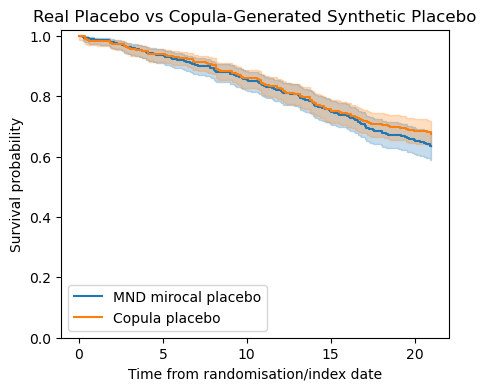

In [65]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(5, 4))

for group in copula_combined["group"].unique():
    dfg = copula_combined[copula_combined["group"] == group]

    kmf.fit(
        durations=dfg["Disease_Duration"],
        event_observed=dfg["Event"],
        label=group
    )

    kmf.plot_survival_function(ci_show=True)

plt.xlabel("Time from randomisation/index date")
plt.ylabel("Survival probability")
plt.title("Real Placebo vs Copula-Generated Synthetic Placebo")
plt.ylim(0, 1.02)
plt.show()

In [66]:
def compute_rmst_from_km(df, tau=18):
    kmf = KaplanMeierFitter()
    kmf.fit(df["Disease_Duration"], df["Event"])

    surv = kmf.survival_function_.reset_index()
    surv.columns = ["time", "survival"]

    surv = pd.concat([
        pd.DataFrame({"time": [0], "survival": [1.0]}),
        surv
    ], ignore_index=True)

    surv = surv[surv["time"] <= tau].copy()

    if surv["time"].max() < tau:
        surv = pd.concat([
            surv,
            pd.DataFrame({
                "time": [tau],
                "survival": [surv["survival"].iloc[-1]]
            })
        ], ignore_index=True)

    times = surv["time"].values
    survival = surv["survival"].values

    rmst = np.sum(np.diff(times) * survival[:-1])

    return rmst

rmst_real = compute_rmst_from_km(copula_combined[copula_combined["group"] == "MND mirocal placebo"],tau = tau)

copula_rmst_synthetic = compute_rmst_from_km(copula_combined[copula_combined["group"] == "Copula placebo"],tau=tau)

print("Real placebo RMST:", rmst_real)
print("Synthetic placebo RMST:", copula_rmst_synthetic)
print("Difference:", copula_rmst_synthetic - rmst_real)


Real placebo RMST: 17.502620977730587
Synthetic placebo RMST: 17.68736666666667
Difference: 0.18474568893608279


In [67]:
n_sim = 1000
rmst_results = []

for seed in range(n_sim):
    copula_synthetic_outcomes = sample_event_times_from_survival(
        copula_survival_curves,
        tau=tau,
        random_state=seed
    )

    sim_df = copula_synthetic_outcomes.copy()
    sim_df["group"] = "synthetic_placebo"

    rmst_sim = compute_rmst_from_km(sim_df, tau=tau)

    rmst_results.append(rmst_sim)

rmst_results = np.array(rmst_results)

print("Mean synthetic RMST:", rmst_results.mean())
print("95% simulation interval:", np.percentile(rmst_results, [2.5, 97.5]))
print("Real placebo RMST:", rmst_real)

Mean synthetic RMST: 17.548717666666672
95% simulation interval: [17.06919667 18.02668   ]
Real placebo RMST: 17.502620977730587


In [68]:
lower, upper = np.percentile(rmst_results, [2.5, 97.5])

if lower <= rmst_real <= upper:
    print("Real placebo RMST lies within the synthetic placebo simulation interval.")
else:
    print("Real placebo RMST lies outside the synthetic placebo simulation interval.")

Real placebo RMST lies within the synthetic placebo simulation interval.


#### ***Implementing CTGAN***

In [69]:
# !pip install sdv lifelines pandas numpy matplotlib scikit-learn

In [70]:
# df_model.head(2)
# Drop or impute missing values before CTGAN
ctgan_train = df_model.dropna().reset_index(drop=True)

In [71]:
# Tell SDV what each column means
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(ctgan_train)

# Optional but recommended: explicitly correct column types
metadata.update_column("Age", sdtype="numerical")
metadata.update_column("ALSFRS", sdtype="numerical")
metadata.update_column("Vital_capacity", sdtype="numerical")
metadata.update_column("Diagnostic_Delay", sdtype="numerical")

metadata.update_column("Sex_Male", sdtype="categorical")
metadata.update_column("Onset_Limb", sdtype="categorical")
metadata.update_column("El_Escorial", sdtype="categorical")

In [72]:
# Fit CTGAN
from sdv.single_table import CTGANSynthesizer

ctgan = CTGANSynthesizer(
    metadata,
    epochs=200,
    verbose=True
)

ctgan.fit(ctgan_train)

Gen. (-00.48) | Discrim. (-00.09): 100%|██████████| 200/200 [00:09<00:00, 22.15it/s]


In [73]:
# Generate synthetic patients
n_synthetic = 500

ctgan_synthetic_patients = ctgan.sample(num_rows=n_synthetic)

ctgan_synthetic_patients.head()


,Age,ALSFRS,Vital_capacity,Diagnostic_Delay,Sex_Male,Onset_Limb,El_Escorial
0,65.254578,42.11,78.28,7.222489,0,1,0
1,62.783998,30.82,70.00,10.017485,0,1,1
2,73.377969,32.33,81.95,13.195795,0,1,1
3,75.940000,39.46,70.87,2.683722,1,1,1
4,74.485987,35.00,98.10,1.791364,1,1,0


In [75]:
ctgan_synthetic_patients.describe()

,Age,ALSFRS,Vital_capacity,Diagnostic_Delay,Sex_Male,Onset_Limb,El_Escorial
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,66.150653,33.061660,82.357520,12.231867,0.552000,0.656000,0.580000
std,11.652995,7.377399,13.154415,9.937808,0.497787,0.475517,0.494053
min,23.050605,19.000000,70.000000,0.000000,0.000000,0.000000,0.000000
25%,60.634508,28.117500,70.000000,5.348293,0.000000,0.000000,0.000000
50%,70.580430,34.210000,78.415000,10.716001,1.000000,1.000000,1.000000
75%,75.940000,38.370000,91.245000,15.551606,1.000000,1.000000,1.000000
max,75.940000,48.000000,126.870000,53.942181,1.000000,1.000000,1.000000


In [76]:
# clinical constraints
# synthetic_patients["alsfrs"] = synthetic_patients["alsfrs"].clip(0, 48)
# synthetic_patients["svc"] = synthetic_patients["svc"].clip(0, 150)
# synthetic_patients["age"] = synthetic_patients["age"].clip(18, 100)
# synthetic_patients["diagnostic_delay"] = synthetic_patients["diagnostic_delay"].clip(0, 60)

In [77]:
# Encode synthetic patients the same way

# Align columns with Cox training design matrix
cox_feature_cols = [
    col for col in matched_mnd_miros.drop(columns=['subject_id', 'slope', 'weight']).columns
    if col not in ["Disease_Duration", "Event"]
]

ctgan_synthetic_patients = ctgan_synthetic_patients.reindex(
    columns=cox_feature_cols,
    fill_value=0
)
ctgan_synthetic_patients.head(3)

,Vital_capacity,Age,Diagnostic_Delay,ALSFRS,El_Escorial,Onset_Limb,Sex_Male
0,78.28,65.254578,7.222489,42.11,0,1,0
1,70.00,62.783998,10.017485,30.82,1,1,0
2,81.95,73.377969,13.195795,32.33,1,1,0


In [79]:
time_grid = np.linspace(0, tau, 181)

ctgan_surv_curves = cph_synthetic.predict_survival_function(
    ctgan_synthetic_patients,
    times=time_grid
)

# deterministic synthetic placebo curve
ctgan_synthetic_placebo_curve = ctgan_surv_curves.mean(axis=1)

In [ ]:
# plt.figure(figsize=(7, 5))
# plt.plot(
#     ctgan_synthetic_placebo_curve.index,
#     ctgan_synthetic_placebo_curve.values,
#     label="CTGAN synthetic placebo: predicted"
# )

# plt.xlabel("Time from index/randomisation")
# plt.ylabel("Survival probability")
# plt.ylim(0, 1)
# plt.legend()
# plt.show()

In [80]:
# Simulate event times
ctgan_synthetic_outcomes = sample_event_times_from_survival(
    ctgan_surv_curves,
    tau=tau,
    random_state=123
)

ctgan_synthetic_placebo = pd.concat(
    [
        ctgan_synthetic_patients.reset_index(drop=True),
        ctgan_synthetic_outcomes.reset_index(drop=True)
    ],
    axis=1
)

ctgan_synthetic_placebo["group"] = "ctgan synthetic placebo"
ctgan_synthetic_placebo.head()

,Vital_capacity,Age,Diagnostic_Delay,ALSFRS,El_Escorial,Onset_Limb,Sex_Male,Disease_Duration,Event,group
0,78.28,65.254578,7.222489,42.11,0,1,0,21.000000,0,ctgan synthetic placebo
1,70.00,62.783998,10.017485,30.82,1,1,0,2.916667,1,ctgan synthetic placebo
2,81.95,73.377969,13.195795,32.33,1,1,0,12.133333,1,ctgan synthetic placebo
3,70.87,75.940000,2.683722,39.46,1,1,1,5.600000,1,ctgan synthetic placebo
4,98.10,74.485987,1.791364,35.00,0,1,1,10.150000,1,ctgan synthetic placebo


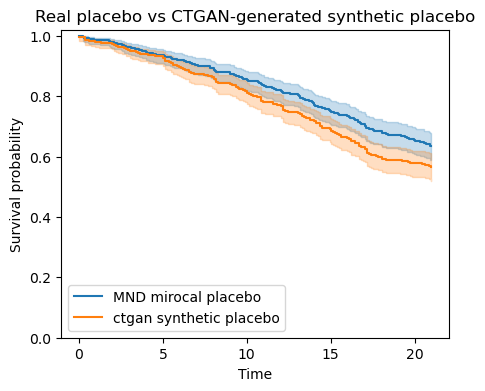

In [82]:
# Validate against real placebo 
ctgan_synthetic_placebo_km = ctgan_synthetic_placebo[["Disease_Duration", "Event", 'group']].copy()
# ctgan_synthetic_placebo_km["group"] = "ctgan_synthetic_placebo"

ctgan_combined = pd.concat([real_placebo, ctgan_synthetic_placebo_km], ignore_index=True)

kmf = KaplanMeierFitter()

plt.figure(figsize=(5, 4))

for group in ctgan_combined["group"].unique():
    dfg = ctgan_combined[ctgan_combined["group"] == group]

    kmf.fit(
        durations=dfg["Disease_Duration"],
        event_observed=dfg["Event"],
        label=group
    )

    kmf.plot_survival_function(ci_show=True)

plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.title("Real placebo vs CTGAN-generated synthetic placebo")
plt.ylim(0, 1.02)
plt.legend()
plt.show()

In [83]:
# Compute RMST
rmst_real = compute_rmst_from_km(real_placebo, tau=tau)
rmst_synthetic = compute_rmst_from_km(ctgan_synthetic_placebo_km, tau=tau)

print("Real placebo RMST:", rmst_real)
print("CTGAN synthetic placebo RMST:", rmst_synthetic)
print("Difference:", rmst_synthetic - rmst_real)

Real placebo RMST: 17.502620977730587
CTGAN synthetic placebo RMST: 16.587900000000005
Difference: -0.9147209777305818


In [84]:
n_sim = 1000
rmst_values = []
km_curves = []

eval_times = np.linspace(0, tau, 181)

for seed in range(n_sim):
    ctgan_synthetic_outcomes = sample_event_times_from_survival(
        ctgan_surv_curves,
        tau=tau,
        random_state=seed
    )

    rmst = compute_rmst_from_km(ctgan_synthetic_outcomes, tau=tau)
    rmst_values.append(rmst)

    kmf = KaplanMeierFitter()
    kmf.fit(
        ctgan_synthetic_outcomes["Disease_Duration"],
        ctgan_synthetic_outcomes["Event"]
    )

    km_pred = kmf.predict(eval_times)
    km_curves.append(km_pred.values)

km_curves = np.vstack(km_curves)
rmst_values = np.array(rmst_values)

In [85]:
# Summarise simulation envelope
mean_km = km_curves.mean(axis=0)
lower_km = np.percentile(km_curves, 2.5, axis=0)
upper_km = np.percentile(km_curves, 97.5, axis=0)

In [93]:
# Plot against real placebo
kmf_real = KaplanMeierFitter()
kmf_real.fit(
    real_placebo["Disease_Duration"],
    real_placebo["Event"],
    label="Real placebo"
)

real_surv = kmf_real.predict(eval_times)

plt.figure(figsize=(5, 4))

plt.plot(eval_times, real_surv, label="Real placebo KM")
plt.plot(eval_times, mean_km, label="Mean CTGAN simulated KM")
plt.fill_between(
    eval_times,
    lower_km,
    upper_km,
    alpha=0.2,
    label="95% simulation envelope"
)

plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.title("Real placebo vs repeated CTGAN synthetic placebo simulations")
plt.ylim(0, 1.02)
plt.legend()
# plt.show()

In [87]:
# RMST validation
lower, upper = np.percentile(rmst_values, [2.5, 97.5])

print("Mean CTGAN RMST:", rmst_values.mean())
print("95% simulation interval:", lower, upper)
print("Observed placebo RMST:", rmst_real)

if lower <= rmst_real <= upper:
    print("Observed placebo RMST is compatible with CTGAN synthetic placebo simulations.")
else:
    print("Observed placebo RMST is outside the CTGAN synthetic placebo simulation interval.")

Mean CTGAN RMST: 16.585809333333337
95% simulation interval: 16.082249166666674 17.10066166666667
Observed placebo RMST: 17.502620977730587
Observed placebo RMST is outside the CTGAN synthetic placebo simulation interval.


#### ***Combining all digital twins***

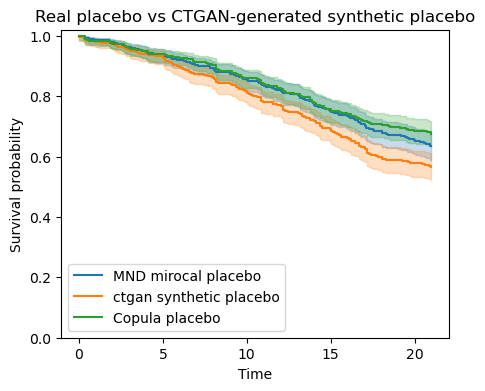

In [92]:
# Validate against real placebo 
ctgan_synthetic_placebo_km = ctgan_synthetic_placebo[["Disease_Duration", "Event", 'group']].copy()
copula_synthetic_placebo_km = copula_synthetic_placebo[["Disease_Duration", "Event", "group"]].copy()

copula_ctgan_combined = pd.concat([real_placebo, ctgan_synthetic_placebo_km, copula_synthetic_placebo_km], ignore_index=True)

kmf = KaplanMeierFitter()

plt.figure(figsize=(5, 4))

for group in copula_ctgan_combined["group"].unique():
    dfg = copula_ctgan_combined[copula_ctgan_combined["group"] == group]

    kmf.fit(
        durations=dfg["Disease_Duration"],
        event_observed=dfg["Event"],
        label=group
    )

    kmf.plot_survival_function(ci_show=True)

plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.title("Real placebo vs CTGAN-generated synthetic placebo")
plt.ylim(0, 1.02)
plt.legend()
plt.show()